In [34]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.7f' % x)

In [5]:
main_df = pd.read_csv("./../output/metric_df.csv")
df = main_df[['admin_name', 'A', 'admin_name.1', 'B', 'A_intersect_B', 'A_intersect_B_perimeter', 'A_union_B', 'metric_2', 'metric_3', 'metric_4', 'metric_5', 'pair']]
df.rename(columns={
    'A_intersect_B': 'inter_area',
    'A_intersect_B_perimeter': 'inter_peri',
    'metric_2': 'inter_area/A_union_B',
    'metric_3': 'inter_area/min',
    'metric_4': 'inter_area/max',
    'metric_5': 'inter_area/peri_sq',
}, inplace=True)

# convert to kilo
df['A'] = df['A']/(1000 ** 2)
df['B'] = df['B']/(1000 ** 2)
df['inter_area'] = df['inter_area']/(1000 ** 2)
df['A_union_B'] = df['A_union_B']/(1000 ** 2)
df['norm_inter_area'] = (df['inter_area'] - df['inter_area'].min()) / (df['inter_area'].max() - df['inter_area'].min())

df[['log_inter_area', 'log_iou', 'log_min', 'log_max', 'log_ap']] = np.log10(
    df[['inter_area', 'inter_area/A_union_B', 'inter_area/min', 'inter_area/max', 'inter_area/peri_sq']] + 1e-20
)
df.head()

,admin_name,A,admin_name.1,B,inter_area,inter_peri,A_union_B,inter_area/A_union_B,inter_area/min,inter_area/max,inter_area/peri_sq,pair,norm_inter_area,log_inter_area,log_iou,log_min,log_max,log_ap
0,bagerhat sadar,271.7185840,bagerhat sadar,271.7185840,271.7185840,7838179959.9434099,271.7185840,1.0000000,1.0000000,1.0000000,0.0346660,91_01,0.1533154,2.4341193,0.0000000,0.0000000,0.0000000,-1.4600959
1,chitalmari,140.2997346,bagerhat sadar,271.7185840,0.0000000,240667989.8338990,412.0183186,0.0000000,0.0000000,0.0000000,0.0000000,91_01,0.0000000,-10.2670862,-12.8820027,-12.4141430,-12.7012055,-12.6485045
2,fakirhat,163.4760642,bagerhat sadar,271.7185840,0.0000000,380796796.3964480,435.1946482,0.0000000,0.0000000,0.0000000,0.0000000,91_01,0.0000000,-10.2590977,-12.8977812,-12.4725519,-12.6932170,-12.8397910
3,kachua,115.5453690,bagerhat sadar,271.7185840,0.0000000,1209889847.4721401,387.2639530,0.0000000,0.0000000,0.0000000,0.0000000,91_01,0.0000000,-9.9182511,-12.5062582,-11.9810037,-12.3523704,-13.0009969
4,morrelganj,429.2820345,bagerhat sadar,271.7185840,0.0000000,36069194.2321772,701.0006185,0.0000000,0.0000000,0.0000000,0.0000000,91_01,0.0000000,-11.4251640,-14.2708816,-13.8592830,-14.0579062,-12.9823004


In [6]:
# stable row identifier
df = df.copy()
df["row_id"] = np.arange(len(df))

log_cols = [
    "log_inter_area",
    "log_iou",
    "log_min",
    "log_max",
    "log_ap",
]

for col in log_cols:
    diff_col = f"diff_{col}"

    # sort by that log column only for calculating consecutive jumps
    temp = df[["row_id", col]].dropna().sort_values(col).copy()

    # difference from previous sorted value
    temp[diff_col] = temp[col].diff().abs()

    # write differences back to original dataframe rows
    df = df.merge(
        temp[["row_id", diff_col]],
        on="row_id",
        how="left"
    )

# df.drop(columns='row_id', inplace=True)

df.head()

,admin_name,A,admin_name.1,B,inter_area,inter_peri,A_union_B,inter_area/A_union_B,inter_area/min,inter_area/max,inter_area/peri_sq,pair,norm_inter_area,log_inter_area,log_iou,log_min,log_max,log_ap,row_id,diff_log_inter_area,diff_log_iou,diff_log_min,diff_log_max,diff_log_ap
0,bagerhat sadar,271.7185840,bagerhat sadar,271.7185840,271.7185840,7838179959.9434099,271.7185840,1.0000000,1.0000000,1.0000000,0.0346660,91_01,0.1533154,2.4341193,0.0000000,0.0000000,0.0000000,-1.4600959,0,0.0000615,0.0000000,0.0000000,0.0000000,0.0000800
1,chitalmari,140.2997346,bagerhat sadar,271.7185840,0.0000000,240667989.8338990,412.0183186,0.0000000,0.0000000,0.0000000,0.0000000,91_01,0.0000000,-10.2670862,-12.8820027,-12.4141430,-12.7012055,-12.6485045,1,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000
2,fakirhat,163.4760642,bagerhat sadar,271.7185840,0.0000000,380796796.3964480,435.1946482,0.0000000,0.0000000,0.0000000,0.0000000,91_01,0.0000000,-10.2590977,-12.8977812,-12.4725519,-12.6932170,-12.8397910,2,0.0012144,0.0000000,0.0013680,0.0000000,0.0000000
3,kachua,115.5453690,bagerhat sadar,271.7185840,0.0000000,1209889847.4721401,387.2639530,0.0000000,0.0000000,0.0000000,0.0000000,91_01,0.0000000,-9.9182511,-12.5062582,-11.9810037,-12.3523704,-13.0009969,3,0.0004236,0.0000000,0.0000000,0.0000000,0.0029591
4,morrelganj,429.2820345,bagerhat sadar,271.7185840,0.0000000,36069194.2321772,701.0006185,0.0000000,0.0000000,0.0000000,0.0000000,91_01,0.0000000,-11.4251640,-14.2708816,-13.8592830,-14.0579062,-12.9823004,4,0.0000000,0.0000000,0.0013094,0.0000000,0.0000000


In [27]:
# df.to_csv('cleaned_metric_df.csv')

metric_map = {
    "inter_area": "log_inter_area",
    "inter_area/A_union_B": "log_iou",
    "inter_area/min": "log_min",
    "inter_area/max": "log_max",
    "inter_area/peri_sq": "log_ap",
}

thresholds = {}
jump_info = {}

for metric_col, log_col in metric_map.items():
    diff_col = f"diff_{log_col}"

    temp = (
        df[["row_id", metric_col, log_col, diff_col]]
        .dropna()
        .sort_values(log_col)
    )

    # For inter_area, inspect both largest and 2nd largest jumps
    ranks = [1, 2] if metric_col == "inter_area" else [1]

    for rank in ranks:
        jump_idx = temp[diff_col].nlargest(rank).index[-1]
        pos = temp.index.get_loc(jump_idx)

        before = temp.iloc[pos - 1]
        after = temp.iloc[pos]

        low = before[metric_col]
        high = after[metric_col]

        threshold_geom = np.sqrt(low * high)
        threshold_arith = (low + high) / 2

        jump_info[(metric_col, rank)] = {
            "before_row_id": before["row_id"],
            "after_row_id": after["row_id"],
            "low": low,
            "high": high,
            "jump": after[diff_col],
            "threshold_geom": threshold_geom,
            "threshold_arith": threshold_arith,
        }

        print(f"{metric_col} | jump rank {rank}")
        print(f"  before row_id: {before['row_id']} | value: {low}")
        print(f"  after  row_id: {after['row_id']} | value: {high}")
        print(f"  jump: {after[diff_col]}")
        print(f"  geometric threshold:  {threshold_geom}")
        print(f"  arithmetic threshold: {threshold_arith}")
        print()

    # default threshold rule
    if metric_col == "inter_area":
        # use 2nd largest jump for inter_area
        thresholds[metric_col] = jump_info[(metric_col, 2)]["threshold_arith"]
    else:
        thresholds[metric_col] = jump_info[(metric_col, 1)]["threshold_geom"]

print("Final thresholds:")
print(thresholds)
# log_inter_area has highest jump at #5555 but if you check it's a difference between
# 3.61e-17 -> 4.97e-22. This is essentially a jump between artifacts.
# Meanwhile the jump in #7730 is from 0.313473 -> 0.000963 [sq. km] which is likely to be real.

inter_area | jump rank 1
  before row_id: 2410.0 | value: 3.6083802612552096e-17
  after  row_id: 5555.0 | value: 3.6083802612552096e-17
  jump: 3.5363764845702867
  geometric threshold:  3.6083802612552096e-17
  arithmetic threshold: 3.6083802612552096e-17

inter_area | jump rank 2
  before row_id: 4518.0 | value: 0.000962589048981667
  after  row_id: 7730.0 | value: 0.31347287682333197
  jump: 2.5127590529886246
  geometric threshold:  0.017370824919471107
  arithmetic threshold: 0.15721773293615682

inter_area/A_union_B | jump rank 1
  before row_id: 4518.0 | value: 9.2622715969742e-07
  after  row_id: 7730.0 | value: 0.0007460468693314
  jump: 2.9060486006288584
  geometric threshold:  2.6287047623914992e-05
  arithmetic threshold: 0.00037348654824554875

inter_area/min | jump rank 1
  before row_id: 4518.0 | value: 1.88479131152525e-06
  after  row_id: 7730.0 | value: 0.0016838145905221
  jump: 2.951030997321432
  geometric threshold:  5.633506111149167e-05
  arithmetic threshold:

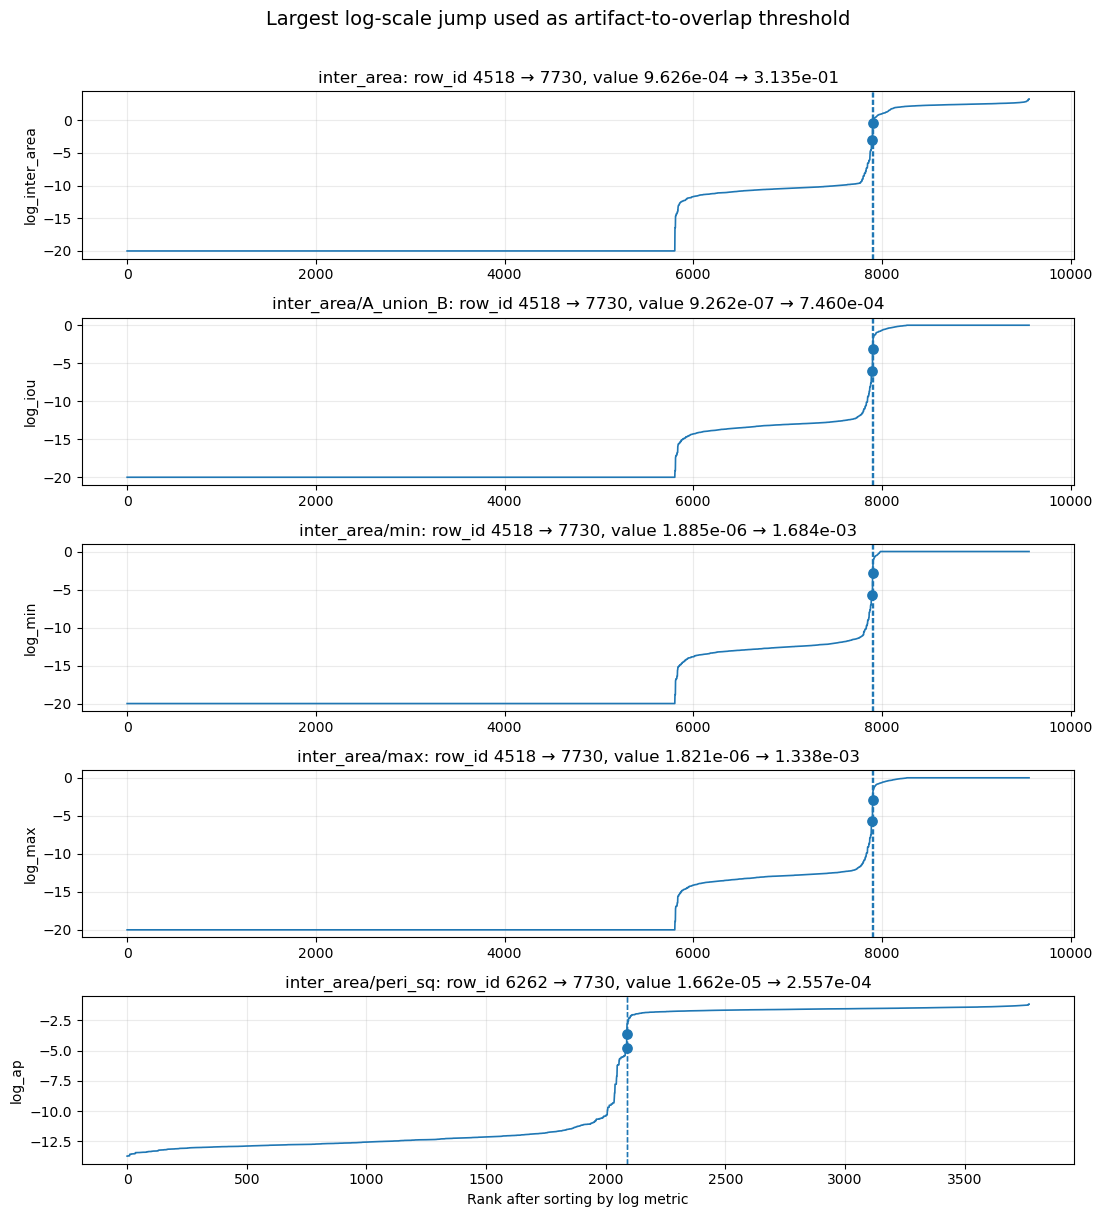

In [40]:
import numpy as np
import matplotlib.pyplot as plt

metric_map = {
    "inter_area": "log_inter_area",
    "inter_area/A_union_B": "log_iou",
    "inter_area/min": "log_min",
    "inter_area/max": "log_max",
    "inter_area/peri_sq": "log_ap",
}

jump_rank = {
    "inter_area": 2,              # use 2nd largest jump for inter_area
    "inter_area/A_union_B": 1,
    "inter_area/min": 1,
    "inter_area/max": 1,
    "inter_area/peri_sq": 1,
}

n = len(metric_map)

fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(11, 2.4 * n),
    sharex=False
)

for ax, (metric_col, log_col) in zip(axes, metric_map.items()):
    diff_col = f"diff_{log_col}"

    temp = (
        df[["row_id", metric_col, log_col, diff_col]]
        .dropna()
        .sort_values(log_col)
        .reset_index(drop=True)
    )

    # selected jump: largest for most metrics, 2nd largest for inter_area
    jump_idx = temp[diff_col].nlargest(jump_rank[metric_col]).index[-1]

    before = temp.iloc[jump_idx - 1]
    after = temp.iloc[jump_idx]

    ax.plot(temp.index, temp[log_col], linewidth=1.2)

    ax.axvline(jump_idx - 1, linestyle="--", linewidth=1)
    ax.axvline(jump_idx, linestyle="--", linewidth=1)

    ax.scatter(
        [jump_idx - 1, jump_idx],
        [before[log_col], after[log_col]],
        s=45,
        zorder=3
    )

    ax.set_title(
        f"{metric_col}: row_id {int(before['row_id'])} → {int(after['row_id'])}, "
        f"value {before[metric_col]:.3e} → {after[metric_col]:.3e}"
    )

    ax.set_ylabel(log_col)
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Rank after sorting by log metric")

fig.suptitle(
    "Largest log-scale jump used as artifact-to-overlap threshold",
    y=1.01,
    fontsize=14
)

plt.tight_layout()
plt.show()

In [9]:
filtered_sets = {}

for metric_col, threshold in thresholds.items():
    filtered_sets[metric_col] = set(
        df.loc[df[metric_col] >= threshold, "row_id"]
    )

    print(
        metric_col,
        "threshold:", threshold,
        "rows kept:", len(filtered_sets[metric_col])
    )

inter_area threshold: 0.157217733 rows kept: 1660
inter_area/A_union_B threshold: 2.6287047623914992e-05 rows kept: 1660
inter_area/min threshold: 5.633506111149167e-05 rows kept: 1660
inter_area/max threshold: 4.9359558401757653e-05 rows kept: 1660
inter_area/peri_sq threshold: 6.519156681304418e-05 rows kept: 1682


In [23]:
# Common rows that survive ALL metric-specific filters
common_rows = set.intersection(*filtered_sets.values())

print("Common rows kept by all metrics:", len(common_rows))
print()

# Rows unique/additional to each metric compared to common intersection
unique_by_metric = {}

for metric_col, row_set in filtered_sets.items():
    unique_rows = row_set - common_rows
    unique_by_metric[metric_col] = unique_rows

    print(metric_col)
    print("  unique rows count:", len(unique_rows))
    print("  row_ids:", sorted(unique_rows))
    print()

Common rows kept by all metrics: 1660

inter_area
  unique rows count: 0
  row_ids: []

inter_area/A_union_B
  unique rows count: 0
  row_ids: []

inter_area/min
  unique rows count: 0
  row_ids: []

inter_area/max
  unique rows count: 0
  row_ids: []

inter_area/peri_sq
  unique rows count: 22
  row_ids: [142, 322, 1394, 1615, 2397, 2410, 3234, 3421, 4527, 4751, 5542, 5555, 6069, 6110, 6519, 6703, 7784, 8003, 8781, 8794, 9285, 9314]

